In [1]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.0005

WINDOWS = {
    "9798_6253": (9798, 6253)
    #"6182_3842": (6253, 3842),
    #"3771_-57": (3842, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult_neg_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Temperatura", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"bm_{window_name}_pc.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 82

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 71

Generando bootstrap...
Significativos: 238 (4.79%)
Cola baja: 83 (34.87%)
Cola alta: 155

Proceso terminado correctamente.


# comprobaciones último día

In [61]:
import pickle

# ==============================
# CARGAR RESULTADOS
# ==============================

with open("results_w2_hoy.pkl", "rb") as f:
    resultados = pickle.load(f)

# ==============================
# EXTRAER PARES NEGATIVOS
# ==============================

pares_negativos = []

especies = resultados["especies"]
matriz_sig = resultados["matriz_significancia"]

n = len(especies)

for i in range(n):
    for j in range(n):

        if i == j:
            continue

        if matriz_sig[i, j] == -1:
            sp1 = especies[i]
            sp2 = especies[j]

            pares_negativos.append((sp1, sp2))

# ==============================
# RESULTADO
# ==============================

print(f"Total pares negativos: {len(pares_negativos)}\n")

for p in pares_negativos:
    print(p)

Total pares negativos: 31

('Corylus', 'Chenopodiaceae')
('Corylus', 'Lotus type')
('Ulmus', 'Lotus type')
('Buxus', 'Poaceae')
('Oleaceae', 'Caryophyllaceae')
('Poaceae', 'Rosaceae')
('Cichorioideae', 'Asteroideae')
('Cichorioideae', 'Liliaceae')
('Asteroideae', 'Ulmus')
('Chenopodiaceae', 'Juniperus')
('Chenopodiaceae', 'Lotus type')
('Plantago', 'Scrophulariaceae')
('Plantago', 'Iridaceae')
('Lotus type', 'Quercus perennifolio')
('Trifolium type', 'Rhamnus')
('Trifolium type', 'Ranunculaceae')
('Trifolium type', 'Ranunculus')
('Rosaceae', 'Tamarix')
('Ribes', 'Artemisia')
('Sedum', 'Alnus')
('Lamiaceae', 'Asteroideae')
('Urticaceae', 'Rhamnus')
('Urticaceae', 'Ranunculaceae')
('Rumex', 'Quercus perennifolio')
('Rumex', 'Artemisia')
('Primulaceae', 'Campanulaceae')
('Scrophulariaceae', 'Cichorioideae')
('Liliaceae', 'Ranunculus')
('Crassulaceae', 'Artemisia')
('Galium', 'Quercus perennifolio')
('Galium', 'Lotus type')


for i,r in enumerate(df_causality.index):
        for j,c in enumerate(df_causality.columns): # data[[x,y]] opposite to the other granger causality test file, which returns y causing x
                                                                    # the rest of the species, not X or Y
            data_tuple = pd.DataFrame({'X': data[i], 'Y': data[j]})

            data_tuple = data_tuple.assign(**conditional_variables)  # add conditional variables to the DataFrame

            if((r == 'Ulmus') & (c == 'Poaceae')):
                print("Data tuple for Ulmus and Poaceae:")
                print(data_tuple)

            try:
                model = VAR(data_tuple)
                results = model.fit(maxlags=1)
                # causality = results.test_causality(caused='Y', causing=['X'], kind='f')

                df_p_values.loc[r, c] = 1 # causality.pvalue
                df_causality.loc[r, c] = results.coefs[0][1][0]

# Comprobación solo dos especies 

(comprobar si está todo el código correcto)

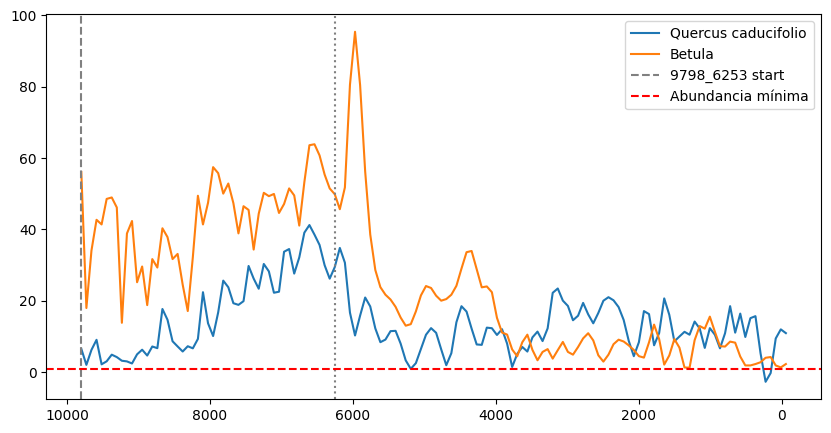


Generando bootstrap...

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 2
         cal BP  Quercus caducifolio     Betula
46  6536.666187            38.535944  63.887973
47  6465.767626            35.647282  60.761529
48  6394.869065            29.963942  55.395093
49  6323.970504            26.191462  51.495784
50  6253.071942            29.434579  49.885487

Quercus caducifolio -> Betula
Original: 0.4888
Bootstrap mean: 0.0008, std: 0.1999
18
p valor:  0.018


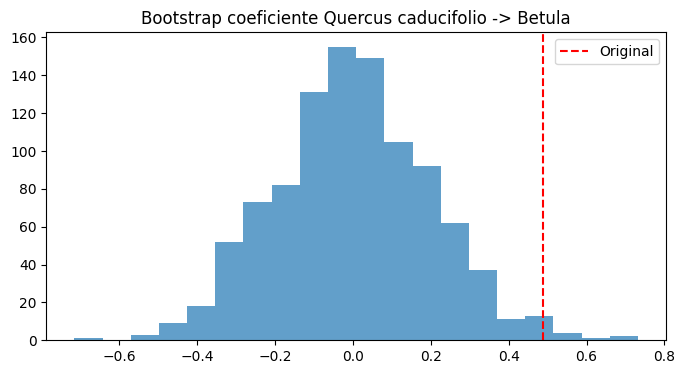

         cal BP     Betula  Quercus caducifolio
46  6536.666187  63.887973            38.535944
47  6465.767626  60.761529            35.647282
48  6394.869065  55.395093            29.963942
49  6323.970504  51.495784            26.191462
50  6253.071942  49.885487            29.434579

Betula -> Quercus caducifolio
Original: 0.0370
Bootstrap mean: -0.0035, std: 0.1010
711
p valor:  0.711


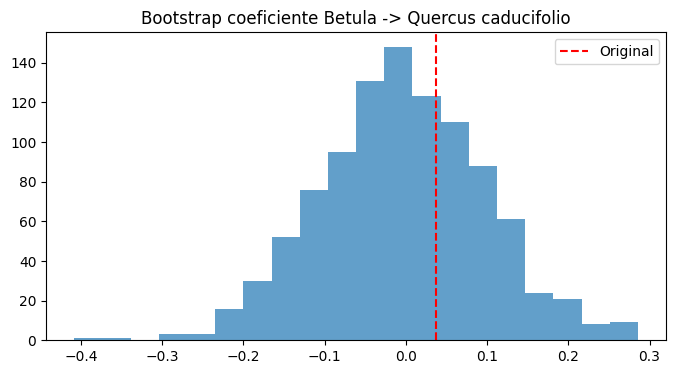

Significativos: 1 (50.00% de válidos)
[[       nan 0.48881757]
 [0.03704315        nan]]

Proceso terminado correctamente.


In [33]:
#lo mismo pero para un par de especies concreto

sp_1="Pinus"
sp_2="Betula"
sp_1='Quercus caducifolio' 


import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 1000
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.9

WINDOWS = {
    "9798_6253": (9798, 6253),
    #"6182_3842": (6253, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque de serie_period
        # inicio puede estar en la primera copia, pero L_actual puede extenderse a la segunda
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values


    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        # fila 1 = destino sp2
        # columna 0 = origen sp1
        return A[1][0]
    
    except:
        return 0

# def coef_sp1_a_sp2_condicional(df, i, j, conditional_variables):
#     """
#     Calcula el coeficiente VAR (lag 1) de i -> j
    
#     Parámetros:
#     - df: DataFrame original (solo para nombres si quieres)
#     - i: serie X (array o serie)
#     - j: serie Y (array o serie)
#     - conditional_variables: dict con variables adicionales
    
#     Devuelve:
#     - coeficiente (float)
#     """

#     try:
#         data_tuple = pd.DataFrame({
#             'X': i,
#             'Y': j
#         })

#         # añadir variables condicionales
#         data_tuple = data_tuple.assign(**conditional_variables)

#         model = VAR(data_tuple)
#         results = model.fit(maxlags=1)

#         return results.coefs[0][1][0]

#     except:
#         return 0

# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult_neg.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP" and c != "Temperatura" and c != "Multiplier"]

# df_original[especies_cols] = df_original[especies_cols].where(
#     df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
# )

np.random.seed(42)

especies_ejemplo = [sp for sp in [sp_1, sp_2] if sp in especies_cols]

#plotear las series originales de las dos especies en una misma grafica
#añadir lineas verticales indicando las ventanas de tiempo
plt.figure(figsize=(10,5))
for sp in especies_ejemplo:
    plt.plot(df_original["cal BP"], df_original[sp], label=sp)
for window_name, (cmin, cmax) in WINDOWS.items():
    plt.axvline(cmin, color="gray", linestyle="--", label=f"{window_name} start")
    plt.axvline(cmax, color="gray", linestyle=":")
plt.gca().invert_xaxis()
#añadir linea horizontal en abundancia 1
plt.axhline(0.9, color="red", linestyle="--", label="Abundancia mínima")
plt.legend()
plt.show()

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

# boot_dfs = [
#     generar_bootstrap_df(df_original, especies_ejemplo)
#     for _ in range(N_BOOTSTRAP)
# ]



# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_ejemplo
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # boot_windows = [
    #     extraer_ventana(df_b, cmin, cmax)
    #     for df_b in boot_dfs
    # ]

    boot_windows = [
        generar_bootstrap_df(df_w, especies_ejemplo)
        for _ in range(N_BOOTSTRAP)
    ]

    

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            print(df_w[["cal BP", sp1, sp2]].tail())

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)
            # coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2, {
            # 'Temp': df_w['Temperatura'],
            # 'Mult': df_w['Multiplier']
            # })

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            #printear media y desviación estándar de coefs_boot
            print(f"\n{sp1} -> {sp2}")
            print(f"Original: {coef_original:.4f}")
            print(f"Bootstrap mean: {coefs_boot.mean():.4f}, std: {coefs_boot.std():.4f}")

            n_extremos = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            print(n_extremos)
            p_valor = (n_extremos) / (len(coefs_boot))
            print("p valor: ", p_valor)
            # Decisión de significancia
            if p_valor < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                else:
                    matriz_sig[i, j] = -1
                    n_low += 1

            # p2_5 = np.percentile(coefs_boot, 2.5)
            # p97_5 = np.percentile(coefs_boot, 97.5)

            # if coef_original < p2_5:

            #     matriz_sig[i, j] = -1
            #     n_sig += 1
            #     n_low += 1

            # elif coef_original > p97_5:

            #     matriz_sig[i, j] = 1
            #     n_sig += 1
            #     n_high += 1

            #plotear histogramas de la distribución de coeficientes bootstrap para el par de especies
            plt.figure(figsize=(8,4))
            plt.hist(coefs_boot, bins=20, alpha=0.7)
            plt.title(f"Bootstrap coeficiente {sp1} -> {sp2}")
            plt.axvline(coef_original, color="red", linestyle="--", label="Original")
            plt.legend()
            plt.show()


    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    # print("\n--- DIAGNÓSTICO ---")

    # print(f"Pares totales evaluados: {total_pairs}")

    # print(f"Coeficientes originales NaN: {nan_original} "
    #       f"({nan_original/total_pairs*100:.2f}%)")

    # print(f"Coeficientes originales válidos: {valid_original} "
    #       f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        # print(f"Fallos bootstrap: {bootstrap_fail} "
        #       f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        # print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    #print(f"Cola baja: {n_low}")
    #print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    print(resultado["matriz_coeficientes"])


print("\nProceso terminado correctamente.")

In [70]:
"""
Histogramas de bootstrap para un par de especies, estilo presentación.
Pensado para mostrar en la diapositiva de "cómo se crea cada enlace".

Uso: llama a plot_bootstrap_pair() desde tu script de análisis,
pasando los datos que ya tienes calculados.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Colores consistentes con las redes coarse
POS_COLOR  = "#0F4C5C"   # teal   – link positivo significativo
#POS_COLOR  = "#f6ad02"
NEG_COLOR  = "#E36414"   # naranja – link negativo significativo
NS_COLOR   = "#b0b0b0"   # gris   – no significativo
BOOT_COLOR = "#6ea067"   # verde muy claro – distribución bootstrap



sp1="Quercus caducifolio"
sp2="Betula"

boot_windows = [
        generar_bootstrap_df(df_w, especies_ejemplo)
        for _ in range(N_BOOTSTRAP)
    ]

coefs_boot_12 = []
coefs_boot_21 = []
for df_b in boot_windows:
    coefs_boot_12.append(coef_sp1_a_sp2_condicional(df_b, sp1, sp2))
    coefs_boot_21.append(coef_sp1_a_sp2_condicional(df_b, sp2, sp1))
    
coefs_boot_12 = np.array(coefs_boot_12)
coefs_boot_21 = np.array(coefs_boot_21)






Guardado en bootstrap_quercus_betula.png


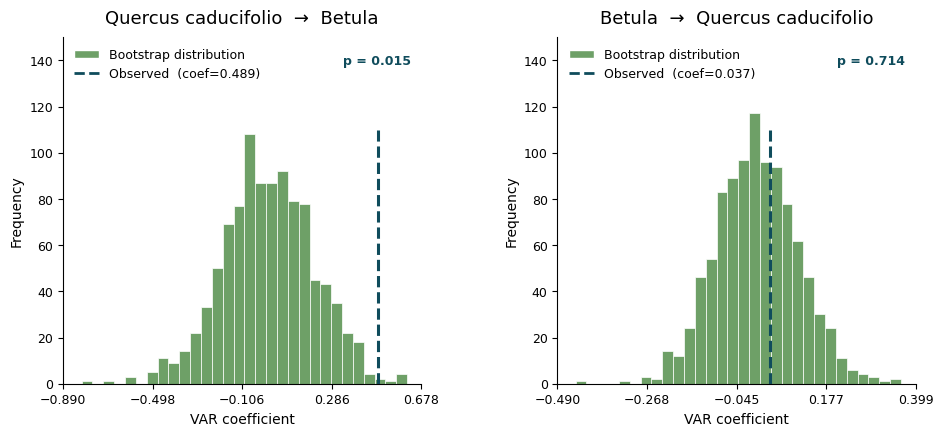

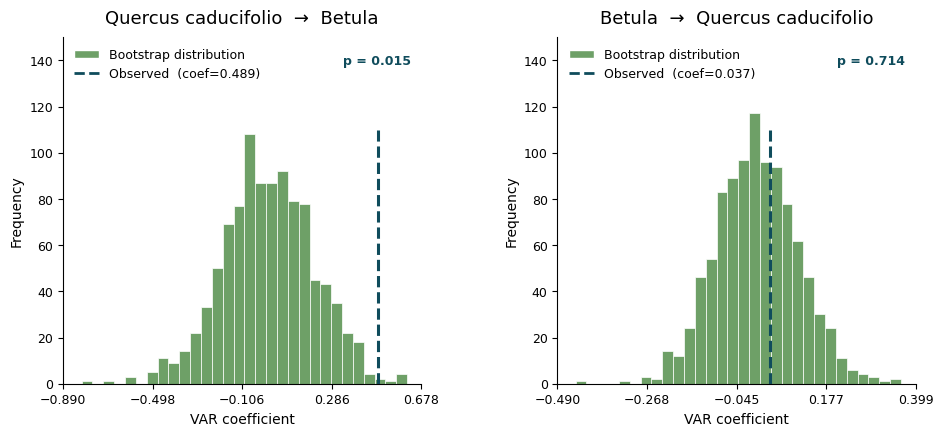

In [77]:

def plot_bootstrap_pair(
    sp1, sp2,
    coefs_boot_12, coef_orig_12, sig_12,   # sp1 → sp2
    coefs_boot_21, coef_orig_21, sig_21,   # sp2 → sp1
    alpha=0.05,
    save_path=None,
    transparent=True,
):
    """
    Dibuja dos histogramas uno al lado del otro:
      izquierda  → sp1 causes sp2
      derecha    → sp2 causes sp1

    Parámetros
    ----------
    coefs_boot_XY : array de coeficientes bootstrap
    coef_orig_XY  : coeficiente original (float)
    sig_XY        : -1 / 0 / 1  (de tu matriz_significancia)
    """

    fig = plt.figure(figsize=(11, 4.5))
    gs  = GridSpec(1, 2, figure=fig, wspace=0.38)

    for col, (boot, orig, sig, direction) in enumerate([
        (coefs_boot_12, coef_orig_12, sig_12, f"{sp1}  →  {sp2}"),
        (coefs_boot_21, coef_orig_21, sig_21, f"{sp2}  →  {sp1}"),
    ]):
        ax = fig.add_subplot(gs[col])

        # Color de la línea vertical según significancia y signo
        if   sig ==  1: line_color = POS_COLOR;  sig_label = "significant (+)"
        elif sig == -1: line_color = NEG_COLOR;  sig_label = "significant (−)"
        else:           line_color = POS_COLOR;   sig_label = "not significant"

        #Histograma bootstrap
        counts, bin_edges, patches = ax.hist(
            boot, bins=30,
            color=BOOT_COLOR, edgecolor="white", linewidth=0.5,
            zorder=2, label="Bootstrap distribution"
        )

        # Sombrear la región de rechazo (colas más extremas que |orig|)
        thresh = np.abs(orig)
        # for patch, left in zip(patches, bin_edges[:-1]):
        #     right = left + (bin_edges[1] - bin_edges[0])
        #     if right <= -thresh or left >= thresh:
        #         patch.set_facecolor("#e0cca3")
        #         patch.set_edgecolor("white")

        # Línea del coeficiente original
        # ax.axvline(orig, 0, 120, color=line_color, linewidth=2.2,
        #            linestyle="--", zorder=4, label=f"Observed coeff.\n({sig_label})")
        
        # Reemplaza ax.axvline(...) por:
        ax.plot(
            [orig, orig], [0, 110],          # ← altura máxima en unidades de datos
            color=line_color, linewidth=2.2,
            linestyle="--", zorder=4,
            label=f"Observed coeff.\n({sig_label})"
        )


        # Líneas de umbral (±|orig|) punteadas muy finas
        #ax.axvline( thresh, color="gray", linewidth=0.8, linestyle=":", zorder=3)
        #ax.axvline(-thresh, color="gray", linewidth=0.8, linestyle=":", zorder=3)

        # p-valor
        p = np.sum(np.abs(boot) >= thresh) / len(boot)
        ax.text(0.97, 0.95, f"p = {p:.3f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9,
                color=line_color,
                # if p < alpha else "#666666",
                fontweight="bold")
                #if p < alpha else "normal"

        # Estilo
        ax.set_title(direction, fontsize=13, fontweight="normal", pad=10)
        ax.set_xlabel("VAR coefficient", fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
        ax.set_ylim(0,150)
        ax.set_xlim(min(boot.min(), orig)*1.1, max(boot.max(), orig)*1.1)
        ax.set_xticks(np.round(np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 5), 3))
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=9)
        #ax.axvline(0, color="#aaaaaa", linewidth=0.7, zorder=1)

        # Leyenda compacta
        handles = [
            mpatches.Patch(facecolor=BOOT_COLOR, edgecolor="white",
                           label="Bootstrap distribution"),
            plt.Line2D([0], [0], color=line_color, linewidth=2,
                       linestyle="--", label=f"Observed  (coef={orig:.3f})"),
        ]
        ax.legend(handles=handles, fontsize=9, frameon=False, loc="upper left")

    # Título general
    # fig.suptitle(
    #     f"Granger causality test:  {sp1}  ↔  {sp2}",
    #     fontsize=13, y=1.02, fontweight="normal"
    # )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight",
                    transparent=transparent,
                    facecolor="none" if transparent else "white")
        print(f"Guardado en {save_path}")

    plt.show()
    return fig



plot_bootstrap_pair(
    sp1 = "Quercus caducifolio",
    sp2 = "Betula",
    coefs_boot_12 = coefs_boot_12,   # array bootstrap Quercus → Betula
    coef_orig_12  = matriz_coef[0,1],
    sig_12 = matriz_sig[0,1],    
    coefs_boot_21 = coefs_boot_21,   # array bootstrap Betula → Quercus
    coef_orig_21  = matriz_coef[1,0],
    sig_21 = matriz_sig[1,0],
    save_path     = "bootstrap_quercus_betula.png",
    transparent   = True,
)
#

Guardado en bootstrap_quercus_betula.png


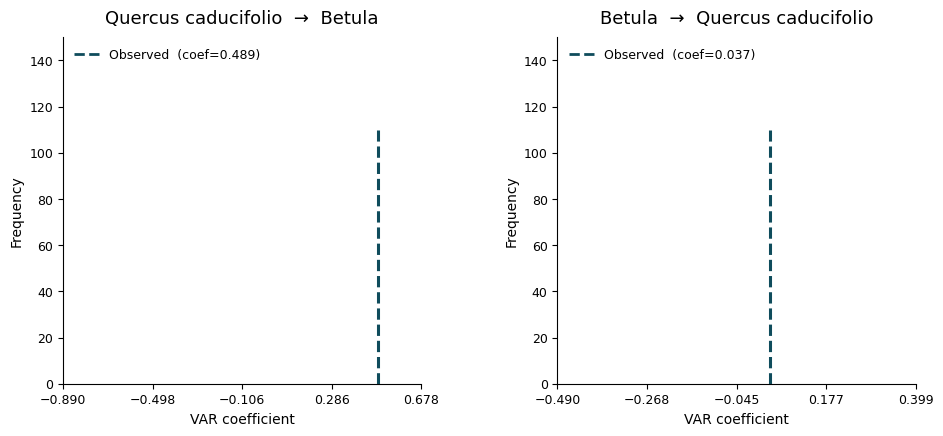

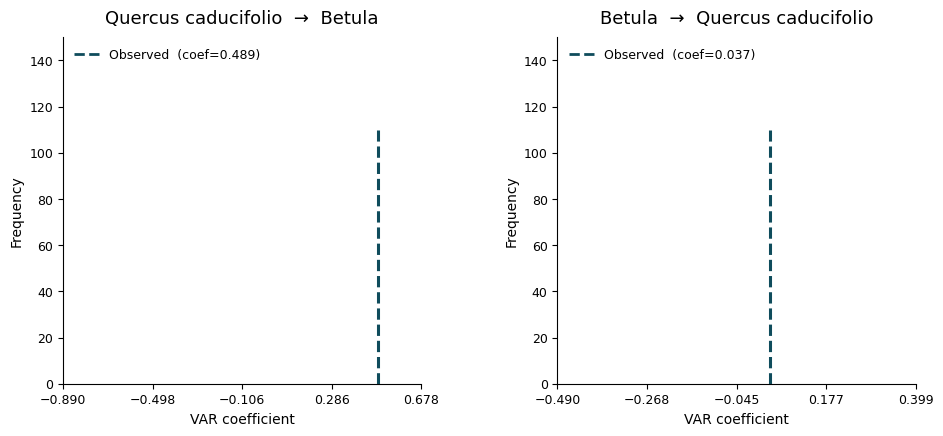

In [76]:

def plot_bootstrap_pair(
    sp1, sp2,
    coefs_boot_12, coef_orig_12, sig_12,   # sp1 → sp2
    coefs_boot_21, coef_orig_21, sig_21,   # sp2 → sp1
    alpha=0.05,
    save_path=None,
    transparent=True,
):
    """
    Dibuja dos histogramas uno al lado del otro:
      izquierda  → sp1 causes sp2
      derecha    → sp2 causes sp1

    Parámetros
    ----------
    coefs_boot_XY : array de coeficientes bootstrap
    coef_orig_XY  : coeficiente original (float)
    sig_XY        : -1 / 0 / 1  (de tu matriz_significancia)
    """

    fig = plt.figure(figsize=(11, 4.5))
    gs  = GridSpec(1, 2, figure=fig, wspace=0.38)

    for col, (boot, orig, sig, direction) in enumerate([
        (coefs_boot_12, coef_orig_12, sig_12, f"{sp1}  →  {sp2}"),
        (coefs_boot_21, coef_orig_21, sig_21, f"{sp2}  →  {sp1}"),
    ]):
        ax = fig.add_subplot(gs[col])

        # Color de la línea vertical según significancia y signo
        if   sig ==  1: line_color = POS_COLOR;  sig_label = "significant (+)"
        elif sig == -1: line_color = NEG_COLOR;  sig_label = "significant (−)"
        else:           line_color = POS_COLOR;   sig_label = "not significant"

        # Histograma bootstrap
        # counts, bin_edges, patches = ax.hist(
        #     boot, bins=30,
        #     color=BOOT_COLOR, edgecolor="white", linewidth=0.5,
        #     zorder=2, label="Bootstrap distribution"
        # )

        # Sombrear la región de rechazo (colas más extremas que |orig|)
        thresh = np.abs(orig)
        # for patch, left in zip(patches, bin_edges[:-1]):
        #     right = left + (bin_edges[1] - bin_edges[0])
        #     if right <= -thresh or left >= thresh:
        #         patch.set_facecolor("#e0cca3")
        #         patch.set_edgecolor("white")

        # Línea del coeficiente original
        # ax.axvline(orig, 0, 120, color=line_color, linewidth=2.2,
        #            linestyle="--", zorder=4, label=f"Observed coeff.\n({sig_label})")
        
        # Reemplaza ax.axvline(...) por:
        ax.plot(
            [orig, orig], [0, 110],          # ← altura máxima en unidades de datos
            color=line_color, linewidth=2.2,
            linestyle="--", zorder=4,
            label=f"Observed coeff.\n({sig_label})"
        )


        # Líneas de umbral (±|orig|) punteadas muy finas
        #ax.axvline( thresh, color="gray", linewidth=0.8, linestyle=":", zorder=3)
        #ax.axvline(-thresh, color="gray", linewidth=0.8, linestyle=":", zorder=3)

        # p-valor
        # p = np.sum(np.abs(boot) >= thresh) / len(boot)
        # ax.text(0.97, 0.95, f"p = {p:.3f}", transform=ax.transAxes,
        #         ha="right", va="top", fontsize=9,
        #         color=line_color,
        #         # if p < alpha else "#666666",
        #         fontweight="bold")
        #         #if p < alpha else "normal"

        # Estilo
        ax.set_title(direction, fontsize=13, fontweight="normal", pad=10)
        ax.set_xlabel("VAR coefficient", fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
        ax.set_ylim(0,150)
        ax.set_xlim(min(boot.min(), orig)*1.1, max(boot.max(), orig)*1.1)
        ax.set_xticks(np.round(np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 5), 3))
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=9)
        #ax.axvline(0, color="#aaaaaa", linewidth=0.7, zorder=1)

        # Leyenda compacta
        handles = [
            # mpatches.Patch(facecolor=BOOT_COLOR, edgecolor="white",
            #                label="Bootstrap distribution"),
            plt.Line2D([0], [0], color=line_color, linewidth=2,
                       linestyle="--", label=f"Observed  (coef={orig:.3f})"),
        ]
        ax.legend(handles=handles, fontsize=9, frameon=False, loc="upper left")

    # Título general
    # fig.suptitle(
    #     f"Granger causality test:  {sp1}  ↔  {sp2}",
    #     fontsize=13, y=1.02, fontweight="normal"
    # )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight",
                    transparent=transparent,
                    facecolor="none" if transparent else "white")
        print(f"Guardado en {save_path}")

    plt.show()
    return fig



plot_bootstrap_pair(
    sp1 = "Quercus caducifolio",
    sp2 = "Betula",
    coefs_boot_12 = coefs_boot_12,   # array bootstrap Quercus → Betula
    coef_orig_12  = matriz_coef[0,1],
    sig_12 = matriz_sig[0,1],    
    coefs_boot_21 = coefs_boot_21,   # array bootstrap Betula → Quercus
    coef_orig_21  = matriz_coef[1,0],
    sig_21 = matriz_sig[1,0],
    save_path     = "bootstrap_quercus_betula.png",
    transparent   = True,
)
#

In [28]:
matriz_coef

array([[       nan, 0.48881757],
       [0.03704315,        nan]])

# CÁLCULO FINAL CORRECTO

- con delta y multipliers (no se bootstrapea)
- las abundancias tras el gam se mantienen iguales, se dejan valores negativos y cercanos a cero
- filtros: 0.9 abundancia mínima y mínimo 3 puntos mayores que cero tras este cambio, y p valor 0.05

In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 1000
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    "9798_6253": (9798, 6253),
    "6182_3842": (6253, 3842),
    "3771_-57": (3842, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult_neg.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Temperatura", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"bm_{window_name}_pc.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 82

VENTANA: 6182_3842
Tamaño ventana: 34 observaciones
Especies válidas en ventana: 53

Generando bootstrap...


KeyboardInterrupt: 

In [ ]:


import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.9

WINDOWS = {
    #"9798_6253": (9798, 6253)
    "6182_3842": (6253, 3842)
    #"3771_-57": (3842, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque de serie_period
        # inicio puede estar en la primera copia, pero L_actual puede extenderse a la segunda
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values


    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        # fila 1 = destino sp2
        # columna 0 = origen sp1
        return A[1][0]
    
    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult_neg.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)


especies_cols = [c for c in df_original.columns if c != "cal BP" and c != "Temperatura" and c != "Multiplier"]
print("len", len(especies_cols))


np.random.seed(42)


# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")


# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # boot_windows = [
    #     extraer_ventana(df_b, cmin, cmax)
    #     for df_b in boot_dfs
    # ]

    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

  



    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            # p2_5 = np.percentile(coefs_boot, 2.5)
            # p97_5 = np.percentile(coefs_boot, 97.5)

            # if coef_original < p2_5:

            #     matriz_sig[i, j] = -1
            #     n_sig += 1
            #     n_low += 1

            # elif coef_original > p97_5:

            #     matriz_sig[i, j] = 1
            #     n_sig += 1
            #     n_high += 1
            sum=0
            for b in coefs_boot:
                sum+=(np.abs(b) >= np.abs(coef_original)).astype(int)

            p_value = sum / len(coefs_boot)

            if (p_value < ALPHA):
                n_sig+=1
                if (coef_original>0):
                    matriz_sig[i, j] = 1
                    n_high += 1
                if (coef_original<0):
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================


    if valid_original > 0:

        # print(f"Fallos bootstrap: {bootstrap_fail} "
        #       f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        # print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    print(f"Cola baja: {n_low}, ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }


print("\nProceso terminado correctamente.")

len 82

Generando bootstrap...

VENTANA: 6182_3842
Tamaño ventana: 34 observaciones
Especies válidas en ventana: 53
Significativos: 97 (3.52% de válidos)
Cola baja: 39, (40.21%)
Cola alta: 58

Proceso terminado correctamente.


calculando percentil 95 de los coeficientes bootstrap y comparando con el coeficiente original, sin hacer corrección de p valores ni nada, solo viendo si el coeficiente original es mayor que el percentil 95 de los bootstrap. Si es así, se considera significativo.

In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 4000
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.9

WINDOWS = {
    #"9798_6253": (9798, 6253)
    "6182_3842": (6253, 3842)
    #"3771_-57": (3842, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult_neg.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Temperatura", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            # count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            # p_value = count / len(coefs_boot)

            # matriz_pval[i, j] = p_value

            # if p_value < ALPHA:
            #     n_sig += 1
            #     if coef_original > 0:
            #         matriz_sig[i, j] = 1
            #         n_high += 1
            #     elif coef_original < 0:
            #         matriz_sig[i, j] = -1
            #         n_low += 1

            pc= np.percentile(abs(coefs_boot), 95) 

            if abs(coef_original) > pc:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}_pc.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

# con interpolación lineal, con delta y multipliers 

In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 4000
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.9

WINDOWS = {
    #"9798_6253": (9798, 6253)
    "6182_3842": (6253, 3842)
    #"3771_-57": (3842, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_interp_delta_mult.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Temperatura", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}_int.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 82

VENTANA: 6182_3842
Tamaño ventana: 34 observaciones
Especies válidas en ventana: 60

Generando bootstrap...
Significativos: 112 (3.16%)
Cola baja: 44 (39.29%)
Cola alta: 68

Proceso terminado correctamente.


In [105]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

WINDOWS = {
    #"9798_6253": (9798, 6253)
    "6182_3842": (6253, 3842)
    #"3771_-57": (3842, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_interp_delta_mult.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Temperatura", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            # 
            
            
            pc= np.percentile(abs(coefs_boot), 95) 

            if abs(coef_original) > pc:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    # with open(f"resultado_{window_name}.pkl", "wb") as f:
    #     pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 82

VENTANA: 6182_3842
Tamaño ventana: 34 observaciones
Especies válidas en ventana: 60

Generando bootstrap...
Significativos: 121 (3.42%)
Cola baja: 48 (39.67%)
Cola alta: 73

Proceso terminado correctamente.


# GARBA GURACHA

In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 1000
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    "w1": (0, 56),
    "w2": (57, 149),
    "w3": (150, 249),
    "w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

In [8]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    #"w1": (0, 56),
    #"w2": (57, 149),
    #"w3": (150, 249),
    "w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w4
Tamaño ventana: 50 observaciones
Especies válidas en ventana: 81

Generando bootstrap...
Significativos: 176 (2.72%)
Cola baja: 61 (34.66%)
Cola alta: 115

Proceso terminado correctamente.


In [9]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

WINDOWS = {
    #"w1": (0, 56),
    "w2": (57, 149)
    #"w3": (150, 249),
    #"w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w2
Tamaño ventana: 93 observaciones
Especies válidas en ventana: 62

Generando bootstrap...
Significativos: 128 (3.38%)
Cola baja: 54 (42.19%)
Cola alta: 74

Proceso terminado correctamente.


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 1000
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    "w1": (0, 56),
    "w2": (57, 149),
    "w3": (150, 249),
    "w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    #df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        #mult = df["Multiplier"].values

        # if (np.std(x) < MIN_VAR or
        #     np.std(y) < MIN_VAR or
        #     np.std(mult) < MIN_VAR):
        #     return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y
            #"Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    # with open(f"resultado_{window_name}.pkl", "wb") as f:
    #     pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w4
Tamaño ventana: 50 observaciones
Especies válidas en ventana: 80

Generando bootstrap...
Significativos: 1018 (16.11%)
Cola baja: 460 (45.19%)
Cola alta: 558

Proceso terminado correctamente.


In [6]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    #"w1": (0, 56)
    #"w2": (57, 149)
    "w3": (150, 249)
    #"w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    #df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        #mult = df["Multiplier"].values

        # if (np.std(x) < MIN_VAR or
        #     np.std(y) < MIN_VAR or
        #     np.std(mult) < MIN_VAR):
        #     return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y
            #"Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    # with open(f"resultado_{window_name}.pkl", "wb") as f:
    #     pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w3
Tamaño ventana: 100 observaciones
Especies válidas en ventana: 69

Generando bootstrap...
Significativos: 193 (4.11%)
Cola baja: 55 (28.50%)
Cola alta: 138

Proceso terminado correctamente.


In [10]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    #"w1": (0, 56),
    "w2": (57, 149)
    #"w3": (150, 249),
    #"w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w2
Tamaño ventana: 93 observaciones
Especies válidas en ventana: 63

Generando bootstrap...
Significativos: 207 (5.30%)
Cola baja: 42 (20.29%)
Cola alta: 165

Proceso terminado correctamente.


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 1000
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    #"w1": (0, 56),
    #"w2": (57, 149),
    #"w3": (150, 249),
    "w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_gg_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 83

VENTANA: w4
Tamaño ventana: 50 observaciones
Especies válidas en ventana: 74

Generando bootstrap...
Significativos: 189 (3.50%)
Cola baja: 55 (29.10%)
Cola alta: 134

Proceso terminado correctamente.


: 

In [5]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 500
MIN_PRESENCIA = 2.5
ALPHA = 0.5
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.1

WINDOWS = {
    "w1": (0, 56),
    "w2": (57, 149),
    "w3": (150, 249),
    "w4": (250, 300)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_comunidades_gam_gg.pkl", "rb") as f:
    df_original = pickle.load(f)

#print(df_original.columns)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [
    c for c in df_original.columns 
    if c not in ["cal BP", "Multiplier"]
]

print("Número de especies:", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (imin, imax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, imin, imax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
        print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"resultado_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

Número de especies: 8

VENTANA: w1
Tamaño ventana: 57 observaciones
Especies válidas en ventana: 7

Generando bootstrap...
Significativos: 21 (50.00%)
Cola baja: 12 (57.14%)
Cola alta: 9

VENTANA: w2
Tamaño ventana: 93 observaciones
Especies válidas en ventana: 8

Generando bootstrap...
Significativos: 26 (46.43%)
Cola baja: 11 (42.31%)
Cola alta: 15

VENTANA: w3
Tamaño ventana: 100 observaciones
Especies válidas en ventana: 8

Generando bootstrap...
Significativos: 31 (55.36%)
Cola baja: 16 (51.61%)
Cola alta: 15

VENTANA: w4
Tamaño ventana: 50 observaciones
Especies válidas en ventana: 8

Generando bootstrap...
Significativos: 26 (46.43%)
Cola baja: 12 (46.15%)
Cola alta: 14

Proceso terminado correctamente.


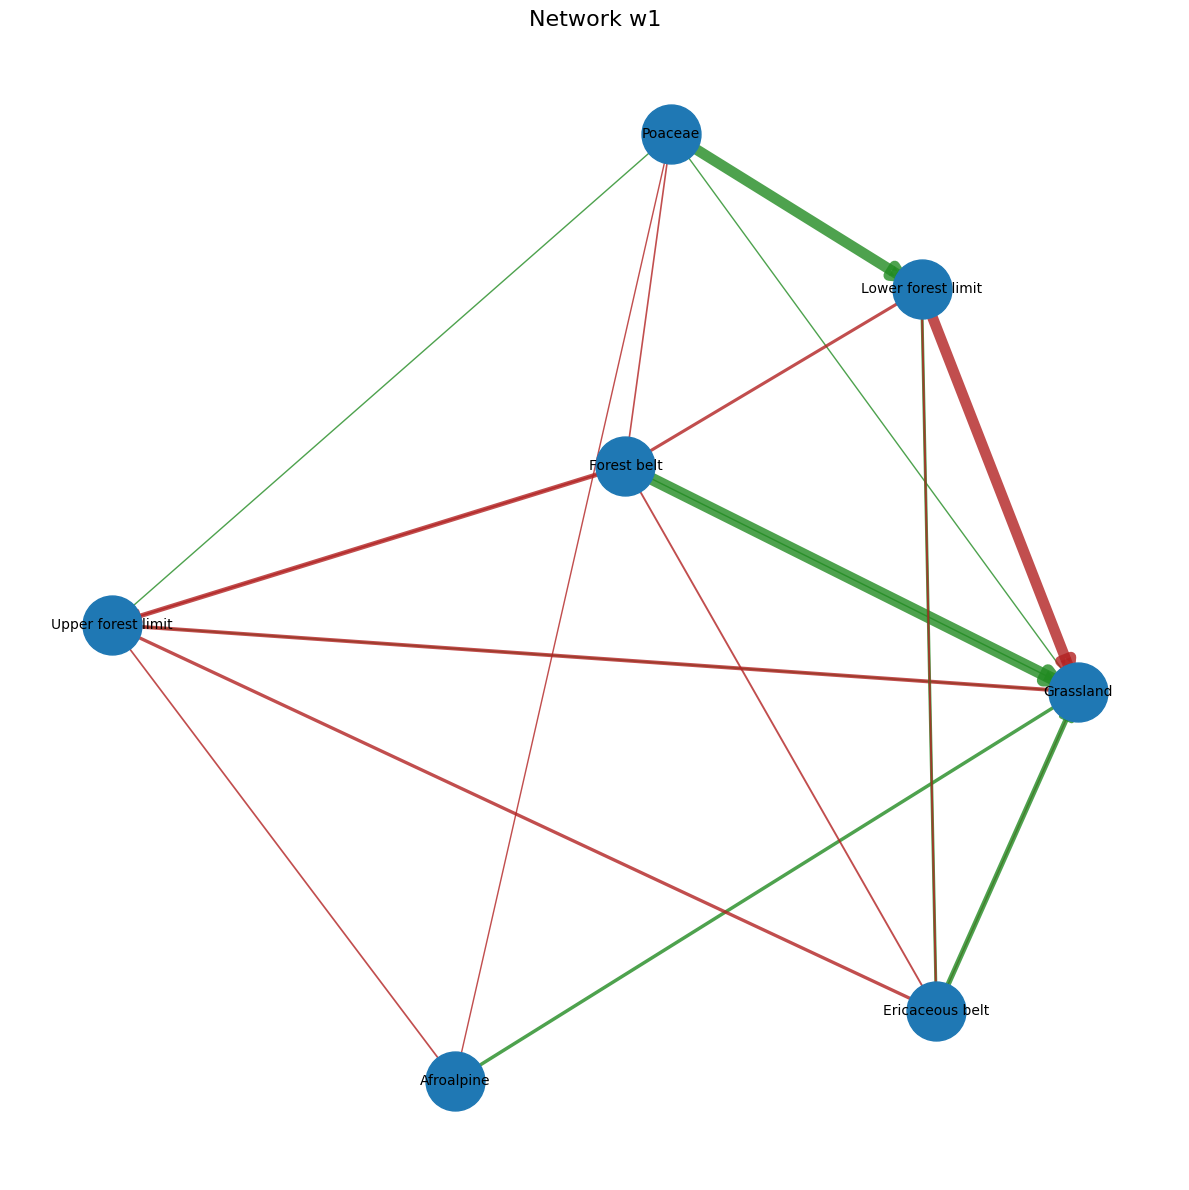

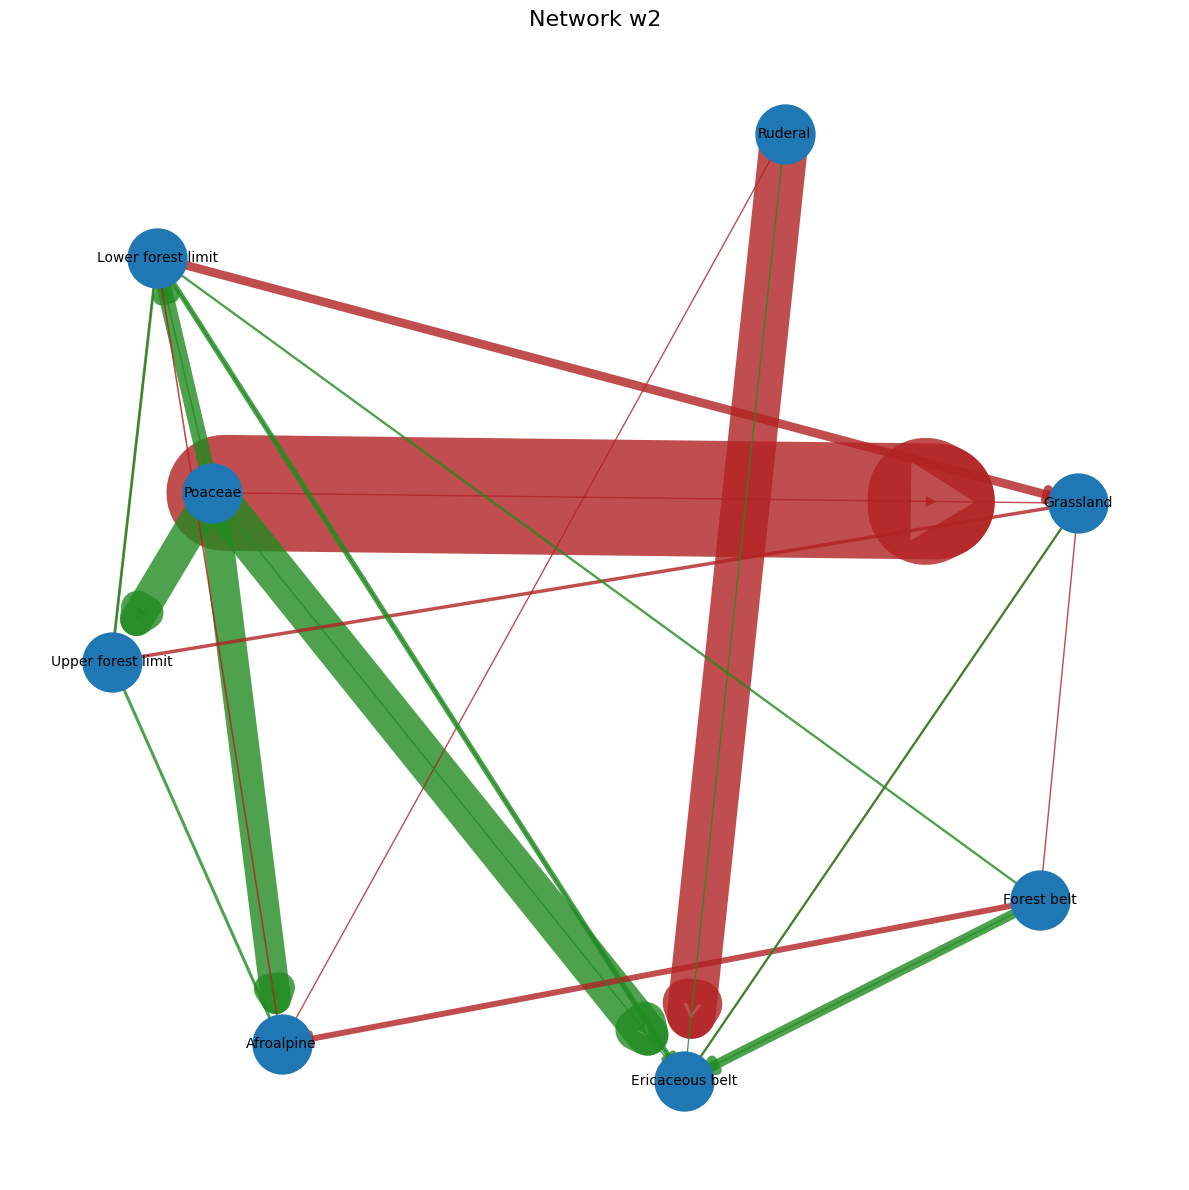

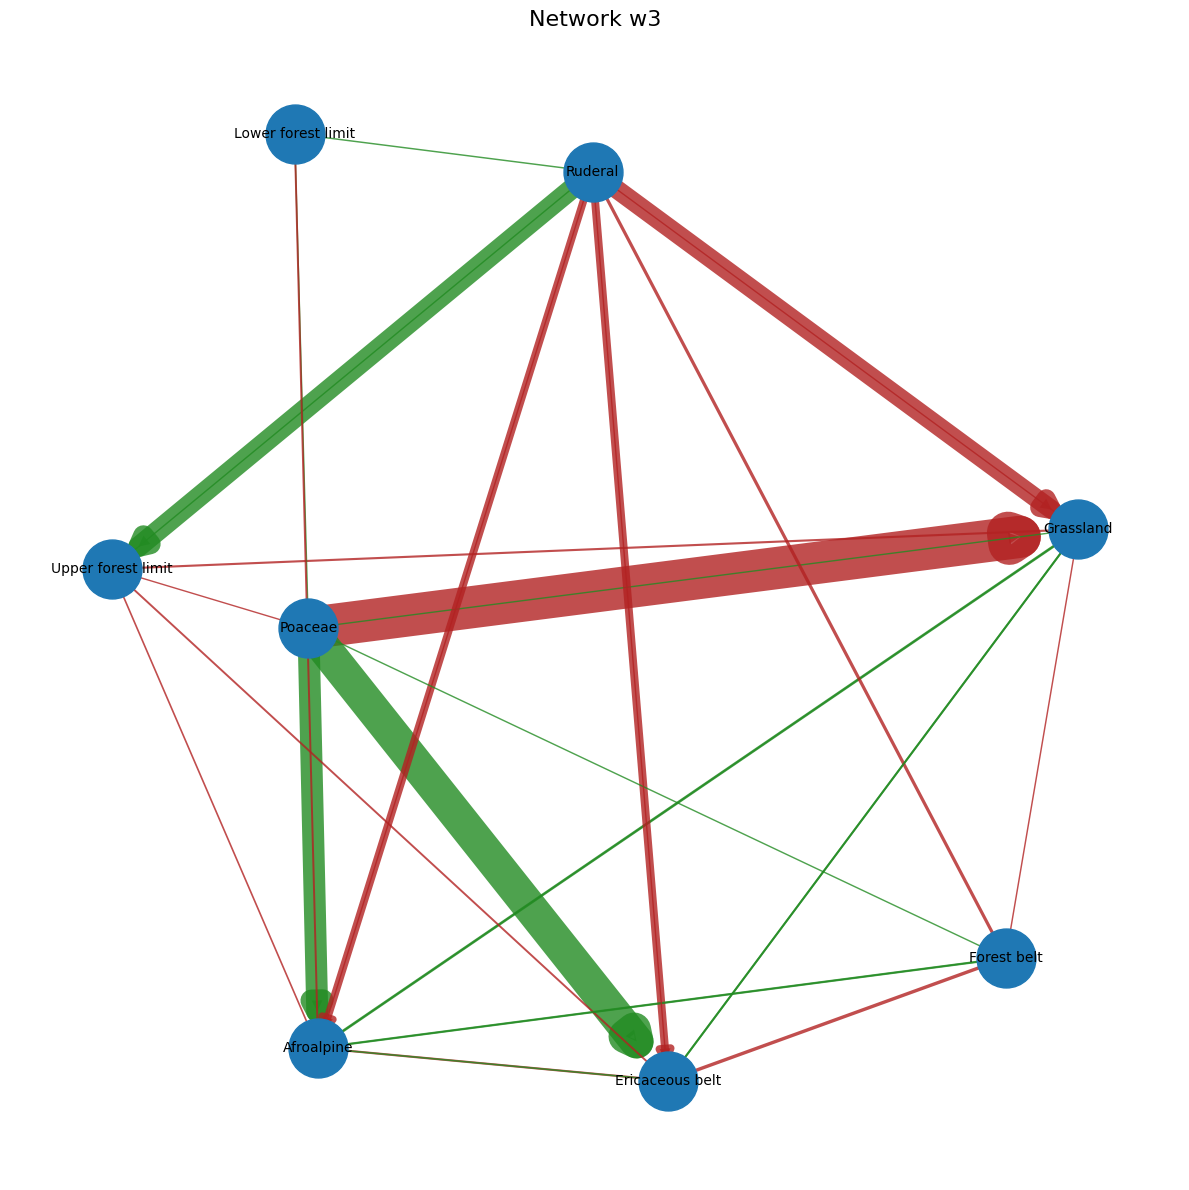

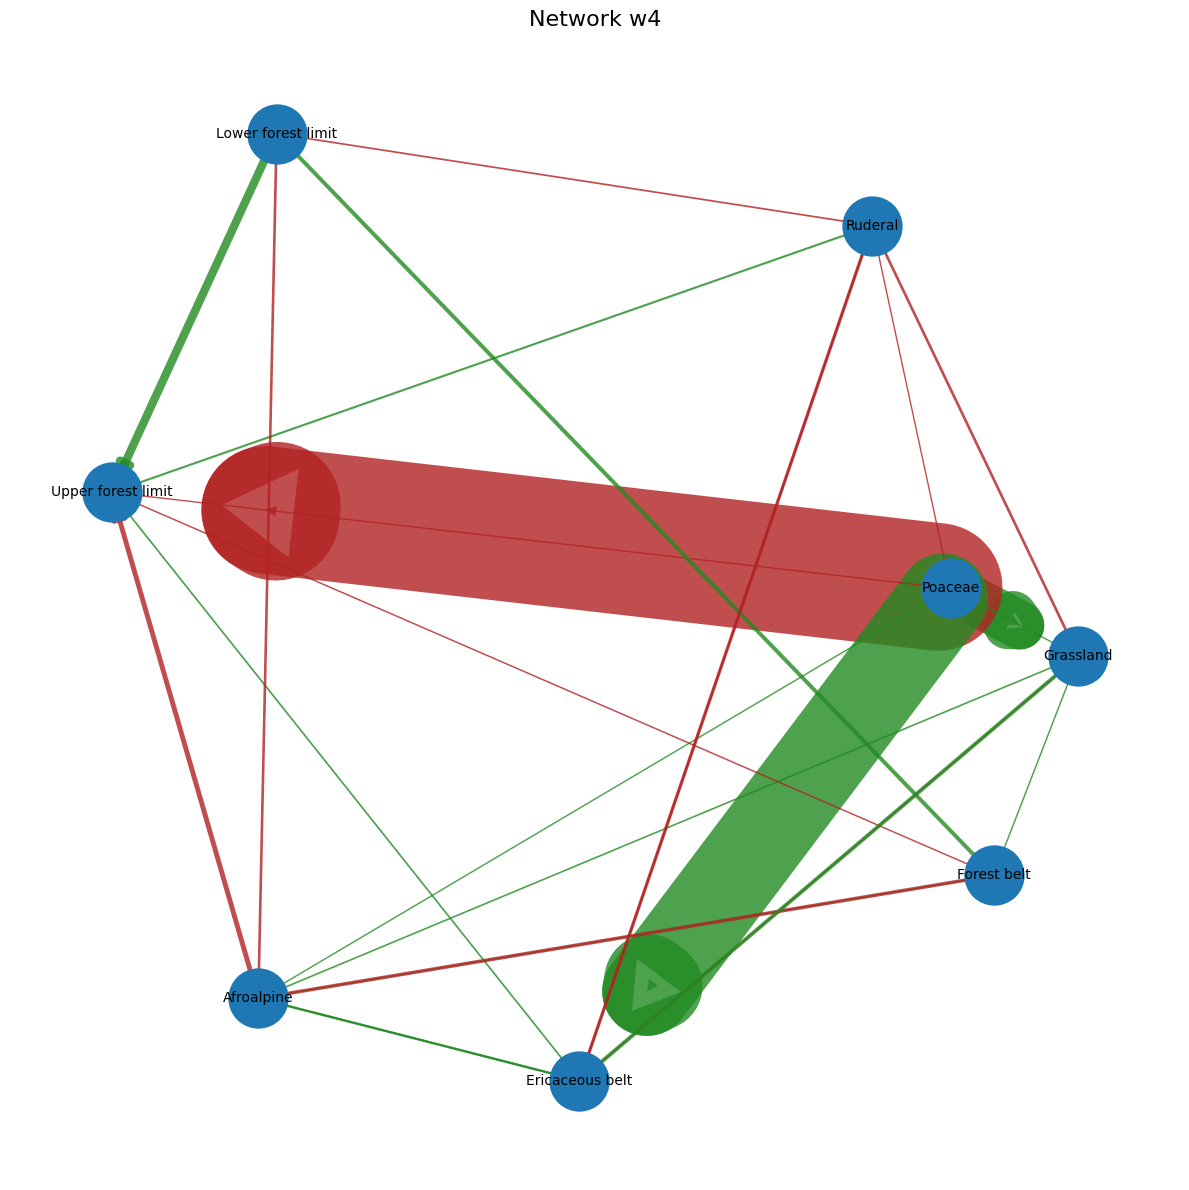

In [6]:
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# =====================================================
# CONFIG
# =====================================================

WINDOWS = ["w1", "w2", "w3", "w4"]

THRESHOLD = 0.0
NODE_SIZE = 1800
FONT_SIZE = 10

# =====================================================
# PLOT RED
# =====================================================

def plot_network(resultado, title="Red"):

    especies = resultado["especies"]

    coef = resultado["matriz_coeficientes"]
    sig = resultado["matriz_significancia"]

    G = nx.DiGraph()

    # =================================================
    # NODOS
    # =================================================

    for sp in especies:
        G.add_node(sp)

    # =================================================
    # ARISTAS
    # =================================================

    edge_colors = []
    edge_widths = []

    for i, sp1 in enumerate(especies):

        for j, sp2 in enumerate(especies):

            if i == j:
                continue

            if sig[i, j] == 0:
                continue

            weight = coef[i, j]

            if np.abs(weight) < THRESHOLD:
                continue

            G.add_edge(sp1, sp2, weight=weight)

            # color según signo
            if weight > 0:
                edge_colors.append("forestgreen")
            else:
                edge_colors.append("firebrick")

            # grosor proporcional
            edge_widths.append(1 + 5 * np.abs(weight))

    # =================================================
    # LAYOUT
    # =================================================

    pos = nx.spring_layout(
        G,
        seed=42,
        k=1.5
    )

    # =================================================
    # FIGURA
    # =================================================

    plt.figure(figsize=(12, 12))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=NODE_SIZE
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=FONT_SIZE
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_colors,
        width=edge_widths,
        arrows=True,
        arrowsize=20,
        alpha=0.8
    )

    plt.title(title, fontsize=16)

    plt.axis("off")

    plt.tight_layout()

    plt.show()


# =====================================================
# CARGAR Y PLOTEAR
# =====================================================

for w in WINDOWS:

    with open(f"resultado_{w}.pkl", "rb") as f:
        resultado = pickle.load(f)

    plot_network(
        resultado,
        title=f"Network {w}"
    )